/tmp/ipykernel_451/2466865868.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, period="6mo")["Close"].dropna()
[*********************100%***********************]  2 of 2 completed


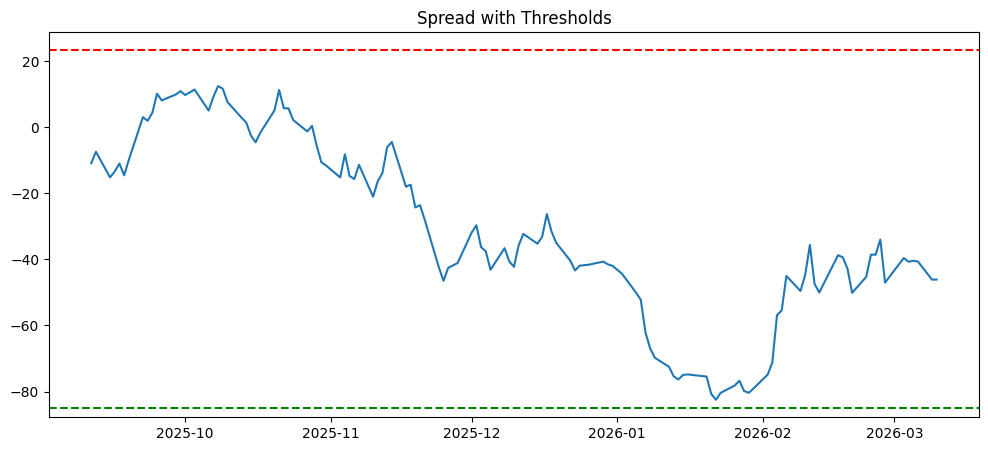

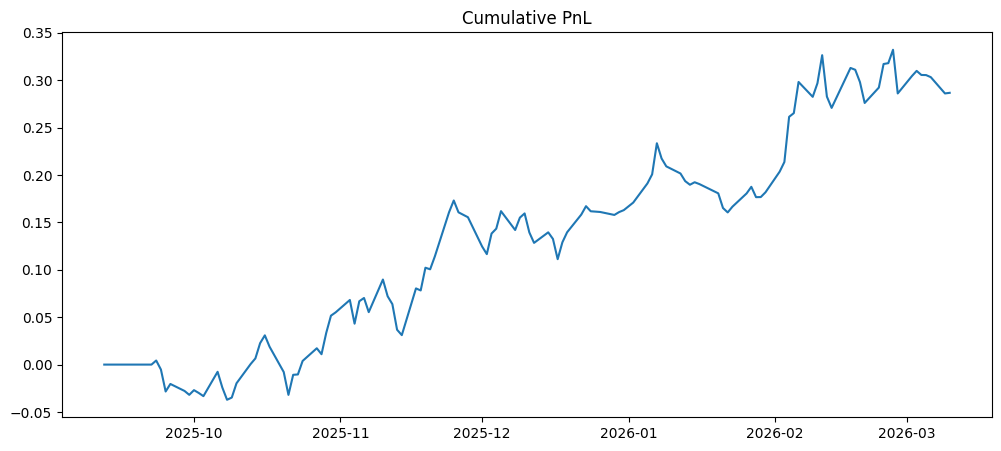

Total Return: 0.28666220257140085
Win Rate: 0.5121951219512195
Trades: 45


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["AAPL", "GOOG"]
df = yf.download(tickers, period="6mo")["Close"].dropna()

spread = df["AAPL"] - df["GOOG"]
spread_mean = spread.mean()
spread_std = spread.std()
z = (spread - spread_mean) / spread_std

long_signal = z < -1
short_signal = z > 1

position = pd.Series(index=df.index, dtype="object")
position[long_signal] = "long"
position[short_signal] = "short"
position = position.ffill().fillna("flat")

returns = df.pct_change().dropna()

pnl = pd.Series(0.0, index=returns.index)
pnl[position.shift(1) == "long"] = returns["AAPL"] - returns["GOOG"]
pnl[position.shift(1) == "short"] = returns["GOOG"] - returns["AAPL"]
pnl_cum = pnl.cumsum()

plt.figure(figsize=(12,5))
plt.plot(spread)
plt.axhline(spread_mean + 2*spread_std, color="red", linestyle="--")
plt.axhline(spread_mean - 2*spread_std, color="green", linestyle="--")
plt.title("Spread with Thresholds")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(pnl_cum)
plt.title("Cumulative PnL")
plt.show()

print("Total Return:", pnl_cum.iloc[-1])
print("Win Rate:", (pnl > 0).mean())
print("Trades:", long_signal.sum() + short_signal.sum())